(remote_stores)=

# Remote dataset mounting

Open a shared dataset, inspect its results, and save your own work without copying the count
matrix. This example uses [Tabula Sapiens](https://tabula-sapiens.sf.czbiohub.org/):
1,136,218 cells from 24 donors. You need an internet
connection and CyteArc's `extra` dependencies; no credentials are required. Allow several
minutes for this example: opening the atlas and creating a mount involve remote metadata reads.

## Plot the published analysis

Open the remote store read-only and load the authors' UMAP:

In [1]:
# Import CyteArc and keep progress output out of the figures.
import cytearc
from cytearc.plotting import CategoricalScale, CellField, ColorScale, NormalizationSpec

cytearc.configure_output(level="ERROR", progress=False)

# Open the full atlas without downloading the dataset archive.
source_uri = "hf://buckets/Nygen/cytebase/cytearc_docs/tabula_sapiens/data.zarr"
source = cytearc.DataStore(
    source_uri,
    zarr_mode="r",
    storage_options={"token": False},
    min_features_per_cell=-1,
)

# Find the UMAP imported from the authors' dataset.
author_umap = cytearc.cytebase.embedding(source)

Started: 2026-10-08T11:03:31.670896Z | Wall time: 52.842 s

Compare the major cell compartments with expression of **MS4A1**, a B-cell marker:

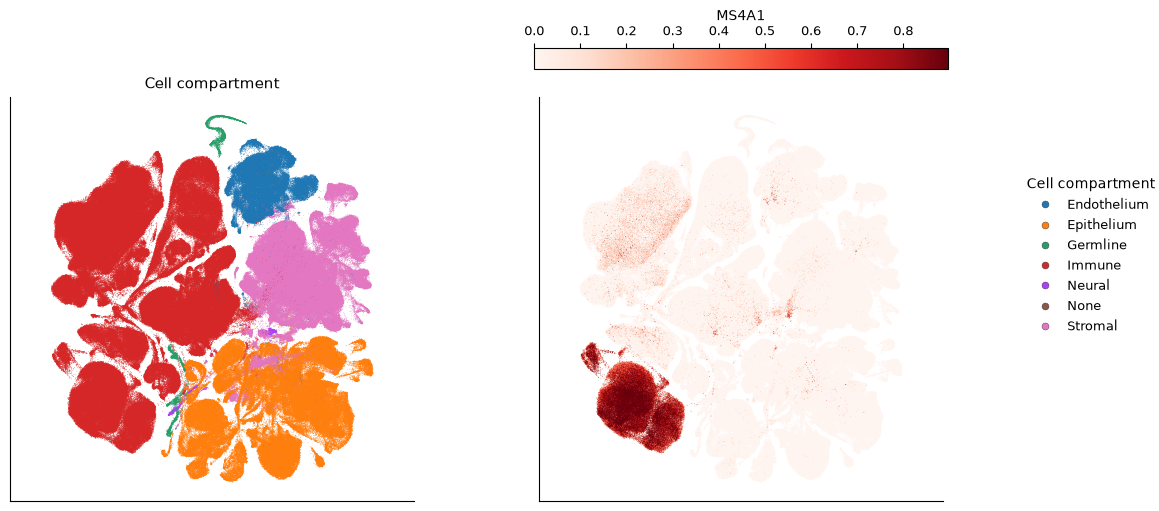

Started: 2026-10-08T11:04:24.521518Z | Wall time: 406.747 s

In [2]:
# Use the authors' UMAP for both compartments and marker expression.
source.plots.embedding(
    layout=author_umap,
    color_by=[CellField("compartment", kind="categorical", label="Cell compartment"), "MS4A1"],
    normalization=NormalizationSpec(transform="log1p"),
    color_scale=ColorScale(cmap="Reds", quantiles=(0, 0.99)),
    sort_values=True,
    point_size=0.2,
    n_columns=2,
    figsize=(12, 5),
    legend_loc="right",
)

The UMAP and compartment labels come from the authors. CyteArc reads the coordinates and
metadata, then reads count blocks for the gene panel and displays log-normalized expression.
The color scale saturates at the 99th percentile to make expression easier to see. Computation
runs in your Python session, and the complete count matrix stays in object storage. Use
additional markers before assigning cell types; see [](annotation.ipynb).

## Save a cell selection locally

A **mount** gives you a writable store for metadata and new results while leaving counts at
their source. Several people can mount the same published dataset and keep separate analyses.
The source can be local or remote; here it is remote and the target is a local directory.
Choose a new or empty path for the target:

In [3]:
# Create a local place for annotations and new analysis results.
mounted = cytearc.mount_datastore(
    source_uri,
    at="tabula_analysis.zarr",
    storage_options={"token": False},
    min_features_per_cell=-1,
)

# Select cells annotated as B cells by the authors.
selected = mounted.cells.fetch_all("cell_type") == "B cell"
mounted.cells.insert("b_cells", selected)

# Check that the selection is present, then count its cells.
assert selected.any()
{"B cells selected": int(selected.sum())}

{'B cells selected': 114495}

Started: 2026-10-08T11:11:11.273683Z | Wall time: 277.977 s

Cell and feature metadata are copied into `tabula_analysis.zarr`, about **165 MB** for this
atlas; count matrices remain in the published store. Your `b_cells` column is local. Other people can mount the same source
and keep their own selections and results.

## Reopen your work

Open the local path again. It remembers where to read the counts:

In [4]:
# Reopen the local mount with anonymous access to its public count source.
reopened = cytearc.DataStore(
    "tabula_analysis.zarr",
    storage_options={"token": False},
    min_features_per_cell=-1,
)

# Open the source afresh to check that its metadata was not changed.
fresh_source = cytearc.DataStore(
    source_uri,
    zarr_mode="r",
    storage_options={"token": False},
    min_features_per_cell=-1,
)

# Check that the selection persisted locally and did not appear in the source.
checks = {
    "selection preserved": bool((reopened.cells.fetch_all("b_cells") == selected).all()),
    "shared source unchanged": "b_cells" not in fresh_source.cells.columns,
}
assert all(checks.values()), checks
checks

{'selection preserved': True, 'shared source unchanged': True}

Started: 2026-10-08T11:15:49.255912Z | Wall time: 44.079 s

Both checks return `True`: the B-cell selection is saved locally and the source metadata is
unchanged. The mount can also read saved artifacts from the source, including its UMAP, without
copying them into the target:

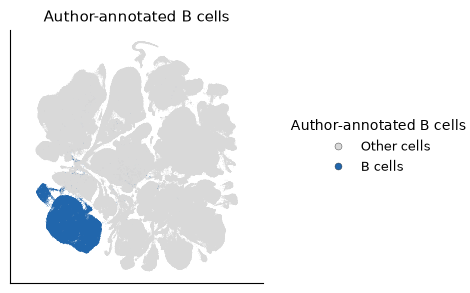

Started: 2026-10-08T11:16:33.338233Z | Wall time: 48.038 s

In [5]:
# Display the local selection on the existing remote UMAP.
reopened.plots.embedding(
    layout=author_umap,
    color_by=CellField("b_cells", kind="categorical", label="Author-annotated B cells"),
    categorical_scale=CategoricalScale(
        palette={False: "#d9d9d9", True: "#2166ac"},
        labels={False: "Other cells", True: "B cells"},
    ),
    point_size=0.2,
    legend_loc="right",
)

Keep `tabula_analysis.zarr` to return to your work. The remote source must remain accessible.
Mounting saves a copy of the metadata, so later changes to the source's annotations do not
silently replace yours.

## Continue with your analysis

- **Analyze the selected B cells:** run
  `mounted.pipeline.run(cell_key="b_cells", label="b_cells")`. The
  [RNA-seq pipeline](../quickstart.ipynb#analyze-your-own-rna-seq-data) reads their count blocks
  from the source and writes new results locally. Saving a selection alone does not change
  which cells the pipeline uses.
- **Find another dataset:** search the [](cytebase.ipynb), then follow the
  [](cytebase_covid19.ipynb) for a study with donor-level comparisons.
- **Connect your own storage:** see [](../reference/remote_storage.md) for S3 and GCS access,
  source requirements, and local scratch settings.
- **Work offline:** download the prepared 100,000-cell sample in the [](../quickstart.ipynb).